# Move Segmentation

Demonstrates `kinema.segmentation.moves` on real bouldering COM data.

**Contents**
1. Load COM from Parquet (written by notebook 01)
2. Speed signal — derivation and smoothing
3. Threshold and active-frame mask
4. Detected moves — table and timeline
5. Per-move stats — duration, peak speed, normalized jerk
6. Write `moves.csv`
7. Synthetic sanity checks — 3-move cycle, no-movement, gap merging

**Algorithm** (intentionally crude for MVP — iterating after real footage):
1. Differentiate smoothed COM → speed magnitude
2. Smooth speed with 0.5 s window (suppresses quantization noise)
3. Threshold at `threshold_quantile` of the signal (default 30th percentile)
4. Maximal above-threshold runs → candidate moves
5. Drop moves shorter than `min_move_duration_sec`
6. Merge consecutive moves separated by rest gap shorter than `min_rest_duration_sec`

In [2]:
import sys
sys.path.insert(0, '../src')

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from kinema.io.com import read_com
from kinema.segmentation.moves import segment_moves, write_moves, Move
from kinema.kinematics.smoothing import savgol_smooth

DATA_DIR = Path('../data/processed')
COM_PATH = DATA_DIR / 'VID-20260528-WA0044_com.parquet'
FPS = 30.0

print(f'COM file : {COM_PATH}')

COM file : ../data/processed/VID-20260528-WA0044_com.parquet


## 1. Load COM

In [3]:
com = read_com(COM_PATH)
com = com.dropna(subset=['com_x', 'com_y', 'com_z']).reset_index(drop=True)

t = com['timestamp_ms'].to_numpy() / 1000.0
duration = t[-1] - t[0]

print(f'Frames : {len(com)}')
print(f'Duration : {duration:.2f} s')
com.head()

Frames : 592
Duration : 19.70 s


,frame_idx,timestamp_ms,com_x,com_y,com_z
0,1,33,0.794834,0.627846,0.061070
1,2,67,0.793308,0.628653,0.060082
2,3,100,0.791844,0.629171,0.058846
3,4,133,0.790037,0.629442,0.058040
4,5,167,0.786472,0.629464,0.060076


## 2. Speed signal

COM speed = ‖∇(com_x, com_y, com_z)‖, computed via `numpy.gradient` (central differences).
A second smoothing pass (0.5 s window) suppresses noise before thresholding.

In [4]:
dt = 1.0 / FPS
vx = np.gradient(com['com_x'].to_numpy(dtype=np.float64), dt)
vy = np.gradient(com['com_y'].to_numpy(dtype=np.float64), dt)
vz = np.gradient(com['com_z'].to_numpy(dtype=np.float64), dt)
speed_raw = np.sqrt(vx**2 + vy**2 + vz**2)
speed_smooth = savgol_smooth(speed_raw, FPS, window_sec=0.5)

THRESHOLD_QUANTILE = 0.3
threshold = float(np.nanquantile(speed_smooth, THRESHOLD_QUANTILE))

print(f'Speed  min / mean / max : {speed_smooth.min():.4f} / {speed_smooth.mean():.4f} / {speed_smooth.max():.4f}')
print(f'Threshold (Q{THRESHOLD_QUANTILE:.0%})       : {threshold:.4f}')

Speed  min / mean / max : 0.0019 / 0.2247 / 1.3707
Threshold (Q30%)       : 0.1152


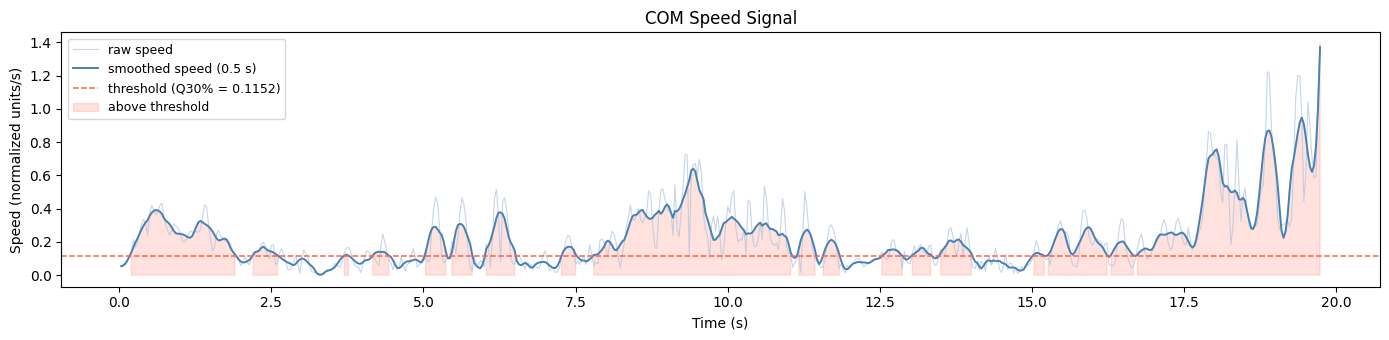

In [5]:
fig, ax = plt.subplots(figsize=(14, 3.5))

ax.plot(t, speed_raw,    color='lightsteelblue', linewidth=0.8, label='raw speed', alpha=0.7)
ax.plot(t, speed_smooth, color='steelblue',      linewidth=1.4, label='smoothed speed (0.5 s)')
ax.axhline(threshold, color='tomato', linestyle='--', linewidth=1.1,
           label=f'threshold (Q{THRESHOLD_QUANTILE:.0%} = {threshold:.4f})')
ax.fill_between(t, 0, speed_smooth, where=speed_smooth > threshold,
                color='tomato', alpha=0.18, label='above threshold')

ax.set_xlabel('Time (s)')
ax.set_ylabel('Speed (normalized units/s)')
ax.set_title('COM Speed Signal')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 3. Threshold and active-frame mask

In [6]:
active = speed_smooth > threshold
pct_active = active.mean() * 100

print(f'Active frames : {active.sum()} / {len(active)}  ({pct_active:.1f}%)')
print(f'Rest   frames : {(~active).sum()} ({100-pct_active:.1f}%)')

Active frames : 414 / 592  (69.9%)
Rest   frames : 178 (30.1%)


## 4. Detected moves

In [7]:
moves = segment_moves(
    com, FPS,
    threshold_quantile=THRESHOLD_QUANTILE,
    min_move_duration_sec=0.2,
    min_rest_duration_sec=0.15,
)

print(f'Moves detected : {len(moves)}')
print()

rows = [
    {
        'index':          m.index,
        'start_time_sec': f'{m.start_time_sec:.2f}',
        'end_time_sec':   f'{m.end_time_sec:.2f}',
        'duration_sec':   f'{m.duration_sec:.2f}',
        'peak_speed':     f'{m.peak_speed:.4f}',
        'mean_speed':     f'{m.mean_speed:.4f}',
        'normalized_jerk': f'{m.normalized_jerk:.2f}',
    }
    for m in moves
]
pd.DataFrame(rows).set_index('index')

Moves detected : 9



,start_time_sec,end_time_sec,duration_sec,peak_speed,mean_speed,normalized_jerk
index,,,,,,
1,0.20,1.90,1.70,0.4346,0.2692,338.53
2,2.20,2.60,0.40,0.1994,0.1412,32.32
3,4.17,4.43,0.27,0.2474,0.1316,12.99
4,5.03,5.80,0.77,0.4698,0.2171,104.37
5,6.03,6.50,0.47,0.5152,0.2558,54.75
6,7.27,7.50,0.23,0.2372,0.1615,8.27
7,7.80,11.83,4.03,0.7283,0.2861,3566.33
8,12.53,14.00,1.47,0.2849,0.1491,457.95
9,15.03,19.73,4.70,1.3902,0.3696,4022.16


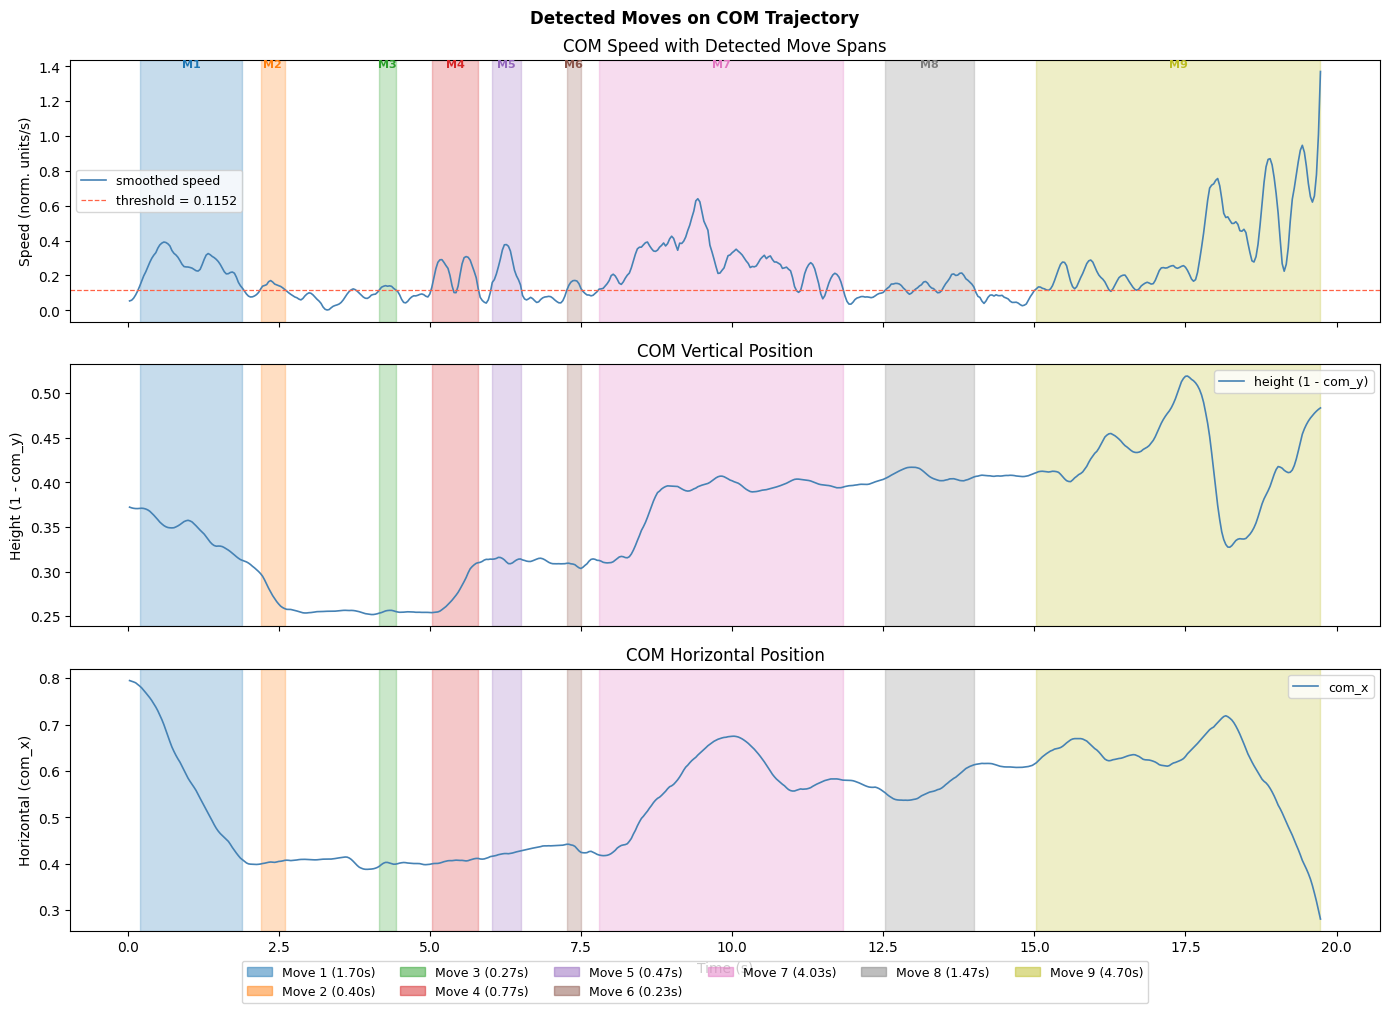

In [8]:
MOVE_COLORS = plt.cm.tab10.colors

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# ── speed + move spans ──────────────────────────────────────────────────────
ax = axes[0]
ax.plot(t, speed_smooth, color='steelblue', linewidth=1.2, label='smoothed speed')
ax.axhline(threshold, color='tomato', linestyle='--', linewidth=0.9,
           label=f'threshold = {threshold:.4f}')
for m in moves:
    color = MOVE_COLORS[(m.index - 1) % len(MOVE_COLORS)]
    ax.axvspan(m.start_time_sec, m.end_time_sec, alpha=0.25, color=color)
    ax.text(
        (m.start_time_sec + m.end_time_sec) / 2, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else speed_smooth.max(),
        f'M{m.index}', ha='center', va='top', fontsize=8, color=color, fontweight='bold'
    )
ax.set_ylabel('Speed (norm. units/s)')
ax.set_title('COM Speed with Detected Move Spans')
ax.legend(fontsize=9)

# ── COM height (y inverted: 1-y puts up at top) ──────────────────────────────
ax = axes[1]
ax.plot(t, 1 - com['com_y'], color='steelblue', linewidth=1.2, label='height (1 - com_y)')
for m in moves:
    color = MOVE_COLORS[(m.index - 1) % len(MOVE_COLORS)]
    ax.axvspan(m.start_time_sec, m.end_time_sec, alpha=0.25, color=color)
ax.set_ylabel('Height (1 - com_y)')
ax.set_title('COM Vertical Position')
ax.legend(fontsize=9)

# ── COM x ────────────────────────────────────────────────────────────────────
ax = axes[2]
ax.plot(t, com['com_x'], color='steelblue', linewidth=1.2, label='com_x')
for m in moves:
    color = MOVE_COLORS[(m.index - 1) % len(MOVE_COLORS)]
    ax.axvspan(m.start_time_sec, m.end_time_sec, alpha=0.25, color=color)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Horizontal (com_x)')
ax.set_title('COM Horizontal Position')
ax.legend(fontsize=9)

patches = [
    mpatches.Patch(color=MOVE_COLORS[(m.index-1) % len(MOVE_COLORS)], alpha=0.5, label=f'Move {m.index} ({m.duration_sec:.2f}s)')
    for m in moves
]
fig.legend(handles=patches, loc='lower center', ncol=min(len(moves), 6), fontsize=9, bbox_to_anchor=(0.5, -0.02))

plt.suptitle('Detected Moves on COM Trajectory', fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Per-move stats

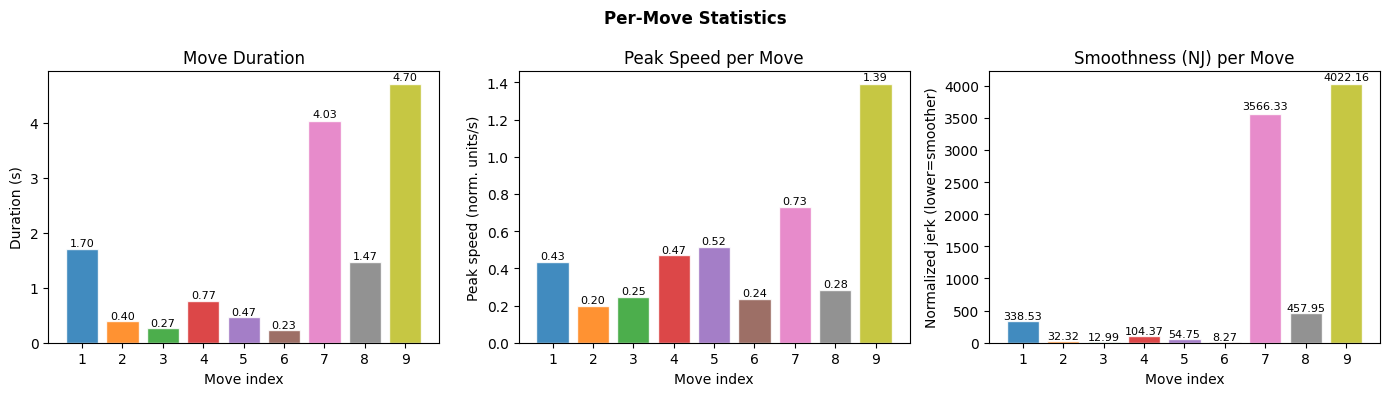

In [9]:
if not moves:
    print('No moves detected — skipping per-move plots.')
else:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    indices = [m.index for m in moves]
    colors  = [MOVE_COLORS[(m.index - 1) % len(MOVE_COLORS)] for m in moves]

    for ax, (attr, ylabel, title) in zip(axes, [
        ('duration_sec',    'Duration (s)',                   'Move Duration'),
        ('peak_speed',      'Peak speed (norm. units/s)',      'Peak Speed per Move'),
        ('normalized_jerk', 'Normalized jerk (lower=smoother)', 'Smoothness (NJ) per Move'),
    ]):
        values = [getattr(m, attr) for m in moves]
        bars = ax.bar(indices, values, color=colors, alpha=0.85, edgecolor='white')
        for bar, val in zip(bars, values):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                val * 1.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8
            )
        ax.set_xlabel('Move index')
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.set_xticks(indices)

    plt.suptitle('Per-Move Statistics', fontweight='bold')
    plt.tight_layout()
    plt.show()

## 6. Write `moves.csv`

In [10]:
MOVES_PATH = DATA_DIR / 'VID-20260528-WA0044_moves.csv'
write_moves(moves, MOVES_PATH)
print(f'Written : {MOVES_PATH}')

# round-trip verify
df_check = pd.read_csv(MOVES_PATH)
assert len(df_check) == len(moves)
print(f'Rows    : {len(df_check)}')
df_check

Written : ../data/processed/VID-20260528-WA0044_moves.csv
Rows    : 9


,index,start_frame,end_frame,start_time_sec,end_time_sec,duration_sec,peak_speed,mean_speed,normalized_jerk
0,1,6,57,0.200,1.900,1.700,0.434571,0.269192,338.533737
1,2,66,78,2.200,2.600,0.400,0.199356,0.141210,32.316125
2,3,125,133,4.167,4.433,0.266,0.247403,0.131647,12.986306
3,4,151,174,5.033,5.800,0.767,0.469787,0.217144,104.365741
4,5,181,195,6.033,6.500,0.467,0.515221,0.255760,54.750275
5,6,218,225,7.267,7.500,0.233,0.237246,0.161488,8.270717
6,7,234,355,7.800,11.833,4.033,0.728253,0.286145,3566.330665
7,8,376,420,12.533,14.000,1.467,0.284867,0.149061,457.950925
8,9,451,592,15.033,19.733,4.700,1.390196,0.369564,4022.162865


## 7. Synthetic sanity checks

Validate the algorithm on known inputs without needing real footage.

In [11]:
def _synth_com(
    total_sec: float,
    fps: float,
    move_intervals: list[tuple[float, float]],
    amplitude: float = 0.05,
) -> pd.DataFrame:
    """Build COM with sinusoidal motion during move_intervals, flat elsewhere."""
    n = int(total_sec * fps)
    t_s = np.arange(n, dtype=np.float64) / fps
    x = np.zeros(n, dtype=np.float64)
    for start, end in move_intervals:
        mask = (t_s >= start) & (t_s < end)
        dur = end - start
        x[mask] = amplitude * np.sin(2 * np.pi * 3.0 * (t_s[mask] - start) / dur)
    frames = np.arange(n, dtype=np.int32)
    return pd.DataFrame({
        'frame_idx':    frames,
        'timestamp_ms': (frames * 1000.0 / fps).astype(np.int64),
        'com_x': x.astype(np.float32),
        'com_y': np.zeros(n, dtype=np.float32),
        'com_z': np.zeros(n, dtype=np.float32),
    })


FPS_SYNTH = 30.0

# --- 3 clear moves ---
com_3 = _synth_com(12.0, FPS_SYNTH, [(2.0, 3.0), (5.0, 6.0), (8.0, 9.0)])
moves_3 = segment_moves(com_3, FPS_SYNTH)
print(f'3-move trajectory → detected {len(moves_3)} moves  (expected 3)')
assert len(moves_3) == 3, f'Expected 3, got {len(moves_3)}'

# --- no movement ---
n_still = int(FPS_SYNTH * 5)
frames_still = np.arange(n_still, dtype=np.int32)
com_still = pd.DataFrame({
    'frame_idx':    frames_still,
    'timestamp_ms': (frames_still * 1000.0 / FPS_SYNTH).astype(np.int64),
    'com_x': np.zeros(n_still, dtype=np.float32),
    'com_y': np.zeros(n_still, dtype=np.float32),
    'com_z': np.zeros(n_still, dtype=np.float32),
})
moves_still = segment_moves(com_still, FPS_SYNTH)
print(f'Stationary trajectory → detected {len(moves_still)} moves  (expected 0)')
assert len(moves_still) == 0

# --- gap merging: two moves 0.05 s apart → merged to 1 ---
com_gap = _synth_com(10.0, FPS_SYNTH, [(2.0, 3.0), (3.05, 4.05)])
moves_gap = segment_moves(com_gap, FPS_SYNTH, min_rest_duration_sec=0.15)
print(f'Gap-merge trajectory  → detected {len(moves_gap)} move(s)  (expected 1)')
assert len(moves_gap) == 1

# --- sub-duration filter: 0.1 s impulse filtered at 0.8 s minimum ---
com_short = _synth_com(14.0, FPS_SYNTH, [(1.0, 3.0), (8.0, 8.1)])
moves_short = segment_moves(com_short, FPS_SYNTH, min_move_duration_sec=0.8)
print(f'Sub-duration filter   → detected {len(moves_short)} move(s)  (expected 1)')
assert len(moves_short) == 1

print()
print('All assertions passed.')

3-move trajectory → detected 3 moves  (expected 3)
Stationary trajectory → detected 0 moves  (expected 0)
Gap-merge trajectory  → detected 1 move(s)  (expected 1)
Sub-duration filter   → detected 1 move(s)  (expected 1)

All assertions passed.


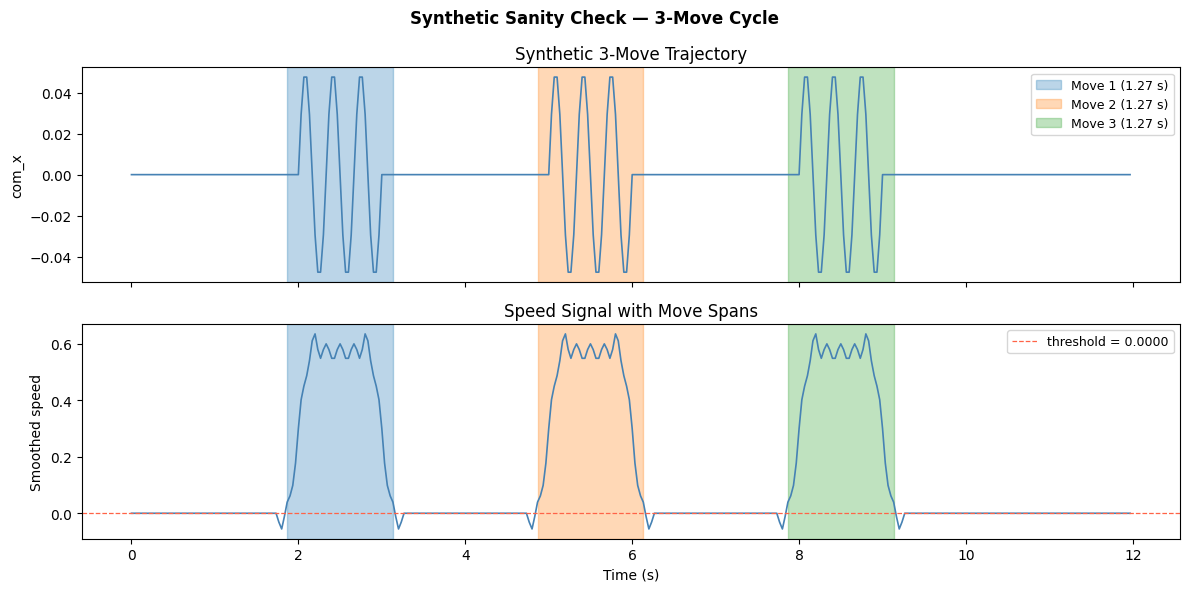

In [12]:
# Visualise the 3-move synthetic case
t3 = com_3['timestamp_ms'].to_numpy() / 1000.0
vx3 = np.gradient(com_3['com_x'].to_numpy(dtype=np.float64), 1.0 / FPS_SYNTH)
vy3 = np.gradient(com_3['com_y'].to_numpy(dtype=np.float64), 1.0 / FPS_SYNTH)
vz3 = np.gradient(com_3['com_z'].to_numpy(dtype=np.float64), 1.0 / FPS_SYNTH)
speed3 = savgol_smooth(np.sqrt(vx3**2 + vy3**2 + vz3**2), FPS_SYNTH, window_sec=0.5)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax = axes[0]
ax.plot(t3, com_3['com_x'], color='steelblue', linewidth=1.2)
for m in moves_3:
    color = MOVE_COLORS[(m.index - 1) % len(MOVE_COLORS)]
    ax.axvspan(m.start_time_sec, m.end_time_sec, alpha=0.3, color=color,
               label=f'Move {m.index} ({m.duration_sec:.2f} s)')
ax.set_ylabel('com_x')
ax.set_title('Synthetic 3-Move Trajectory')
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(t3, speed3, color='steelblue', linewidth=1.2)
thr3 = float(np.nanquantile(speed3, 0.3))
ax.axhline(thr3, color='tomato', linestyle='--', linewidth=0.9, label=f'threshold = {thr3:.4f}')
for m in moves_3:
    color = MOVE_COLORS[(m.index - 1) % len(MOVE_COLORS)]
    ax.axvspan(m.start_time_sec, m.end_time_sec, alpha=0.3, color=color)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Smoothed speed')
ax.set_title('Speed Signal with Move Spans')
ax.legend(fontsize=9)

plt.suptitle('Synthetic Sanity Check — 3-Move Cycle', fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Visual QA — move overlay on footage

Write an annotated video (`moves_overlay.mp4`) with per-frame HUD:
- **Colored border** — one color per move index, gray during rest
- **Top strip** — move label + NJ score + duration, or "REST"
- **Bottom bar** — speed gauge (fills proportionally to peak speed)
- **Yellow dot + 1-second trail** — COM position

Then sample key frames inline for a quick visual sanity check.

In [ ]:
import cv2
import matplotlib.cm as cm
from collections import deque

from kinema.io.video import probe_video, iter_frames

VIDEO_PATH = Path('../data/raw/VID-20260528-WA0044.mp4')
OUT_PATH   = DATA_DIR / 'VID-20260528-WA0044_moves_overlay.mp4'

meta = probe_video(VIDEO_PATH)
print(f'{meta.width}x{meta.height}  {meta.fps:.1f} fps  {meta.duration_sec:.1f}s  {meta.frame_count} frames')

# ── per-frame lookup tables ──────────────────────────────────────────────────
frame_ids  = com['frame_idx'].to_numpy().tolist()
frame_to_speed = dict(zip(frame_ids, speed_raw.tolist()))
frame_to_com   = {
    int(fi): (float(cx), float(cy))
    for fi, cx, cy in zip(com['frame_idx'], com['com_x'], com['com_y'])
}
frame_to_move: dict[int, Move] = {}
for m in moves:
    for fi in range(m.start_frame, m.end_frame + 1):
        frame_to_move[fi] = m

max_speed = float(np.nanmax(speed_raw)) if speed_raw.size > 0 else 1.0


def _tab10_bgr(idx: int) -> tuple[int, int, int]:
    r, g, b, _ = cm.tab10(idx % 10)
    return (int(b * 255), int(g * 255), int(r * 255))


TRACE_FRAMES = int(FPS)  # 1-second trail


def _draw_frame(
    frame_rgb: np.ndarray,
    fi: int,
    ts: float,
    trace: deque,
) -> np.ndarray:
    """Return annotated BGR frame."""
    img = cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2BGR)
    h, w = img.shape[:2]

    move  = frame_to_move.get(fi)
    speed = frame_to_speed.get(fi, 0.0)
    cpos  = frame_to_com.get(fi)

    color = _tab10_bgr(move.index - 1) if move else (100, 100, 100)
    label = (
        f"MOVE {move.index}  {move.duration_sec:.2f}s  NJ={move.normalized_jerk:.0f}"
        if move else "REST"
    )

    # colored border
    bw = max(6, h // 60)
    cv2.rectangle(img, (0, 0), (w - 1, h - 1), color, bw)

    # semi-transparent HUD strip
    strip = img.copy()
    cv2.rectangle(strip, (0, 0), (w, 80), (0, 0, 0), -1)
    img = cv2.addWeighted(strip, 0.55, img, 0.45, 0)

    font = cv2.FONT_HERSHEY_SIMPLEX
    cv2.putText(img, label,                             (12, 36), font, 0.9,  color,          2, cv2.LINE_AA)
    cv2.putText(img, f"t={ts:.2f}s  spd={speed:.4f}", (12, 68), font, 0.65, (180, 180, 180), 1, cv2.LINE_AA)

    # speed gauge at bottom
    bar_h = 14
    bar_w = int(w * min(speed / max_speed, 1.0)) if max_speed > 0 else 0
    cv2.rectangle(img, (0, h - bar_h), (w, h), (30, 30, 30), -1)
    cv2.rectangle(img, (0, h - bar_h), (bar_w, h), color, -1)

    # COM trace + dot
    if cpos is not None and not (np.isnan(cpos[0]) or np.isnan(cpos[1])):
        cx, cy = int(cpos[0] * w), int(cpos[1] * h)
        trace.append((cx, cy))

    if len(trace) >= 2:
        pts = np.array(list(trace), dtype=np.int32).reshape(-1, 1, 2)
        cv2.polylines(img, [pts], isClosed=False, color=(0, 220, 220), thickness=2)
    if trace:
        cv2.circle(img, trace[-1], 10, (0, 255, 255), -1)
        cv2.circle(img, trace[-1], 12, (0,   0,   0), 2)

    return img


# ── write video ──────────────────────────────────────────────────────────────
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
writer = cv2.VideoWriter(str(OUT_PATH), fourcc, meta.fps, (meta.width, meta.height))
trace: deque = deque(maxlen=TRACE_FRAMES)

for fi, ts, frame_rgb in iter_frames(VIDEO_PATH):
    writer.write(_draw_frame(frame_rgb, fi, ts, trace))

writer.release()
print(f'Written : {OUT_PATH}')
print(f'Size    : {OUT_PATH.stat().st_size / 1e6:.1f} MB')

In [ ]:
# ── sample key frames inline ─────────────────────────────────────────────────
# Targets: one rest frame before move 1, then start/mid/end of each move.

targets: list[tuple[str, int]] = []

if moves:
    rest_fi = max(0, moves[0].start_frame - int(FPS * 1.0))
    targets.append((f'REST  t={rest_fi/FPS:.1f}s', rest_fi))
    for m in moves:
        mid_fi = (m.start_frame + m.end_frame) // 2
        targets.append((f'M{m.index} start', m.start_frame))
        targets.append((f'M{m.index} mid',   mid_fi))
        targets.append((f'M{m.index} end',   m.end_frame))

target_set = {fi for _, fi in targets}
label_map  = {fi: lbl for lbl, fi in targets}

captured: dict[int, np.ndarray] = {}
trace2: deque = deque(maxlen=TRACE_FRAMES)

for fi, ts, frame_rgb in iter_frames(VIDEO_PATH):
    # maintain trace for every frame so the trail is correct at sample points
    annotated_bgr = _draw_frame(frame_rgb, fi, ts, trace2)
    if fi in target_set:
        captured[fi] = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB)
    if len(captured) == len(target_set):
        break

# Build ordered list preserving target order
sampled = [(label_map[fi], captured[fi]) for _, fi in targets if fi in captured]

N_COLS = 3
n_rows = (len(sampled) + N_COLS - 1) // N_COLS
fig, axes = plt.subplots(n_rows, N_COLS, figsize=(6 * N_COLS, 5 * n_rows))
axes_flat = np.array(axes).flatten()

for ax, (label, img) in zip(axes_flat, sampled):
    ax.imshow(img)
    ax.set_title(label, fontsize=9, fontweight='bold')
    ax.axis('off')
for ax in axes_flat[len(sampled):]:
    ax.set_visible(False)

plt.suptitle('Move Overlay — Key Frame QA', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()
print(f'Showed {len(sampled)} frames.  Full annotated video: {OUT_PATH.name}')